In [1]:
import os
import json
import numpy as np
from src.betan_predictor import *

## Train model

In [ ]:

# Example usage
main_dirs = [
    "/scratch/project_2009007/data_JET_1H/success",
    "/scratch/project_2009007/data_JET_2H/success",
    "/scratch/project_2009007/data_JET_3H/success",
    "/scratch/project_2009007/data_DIIID/success",
    "/scratch/project_2009007/data_TCV/success",
    "/scratch/project_2009007/data_JT60SA/success",
]

X, y = load_dataset(main_dirs)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

print("First sample features:", X[0])
print("First label:", y[0])

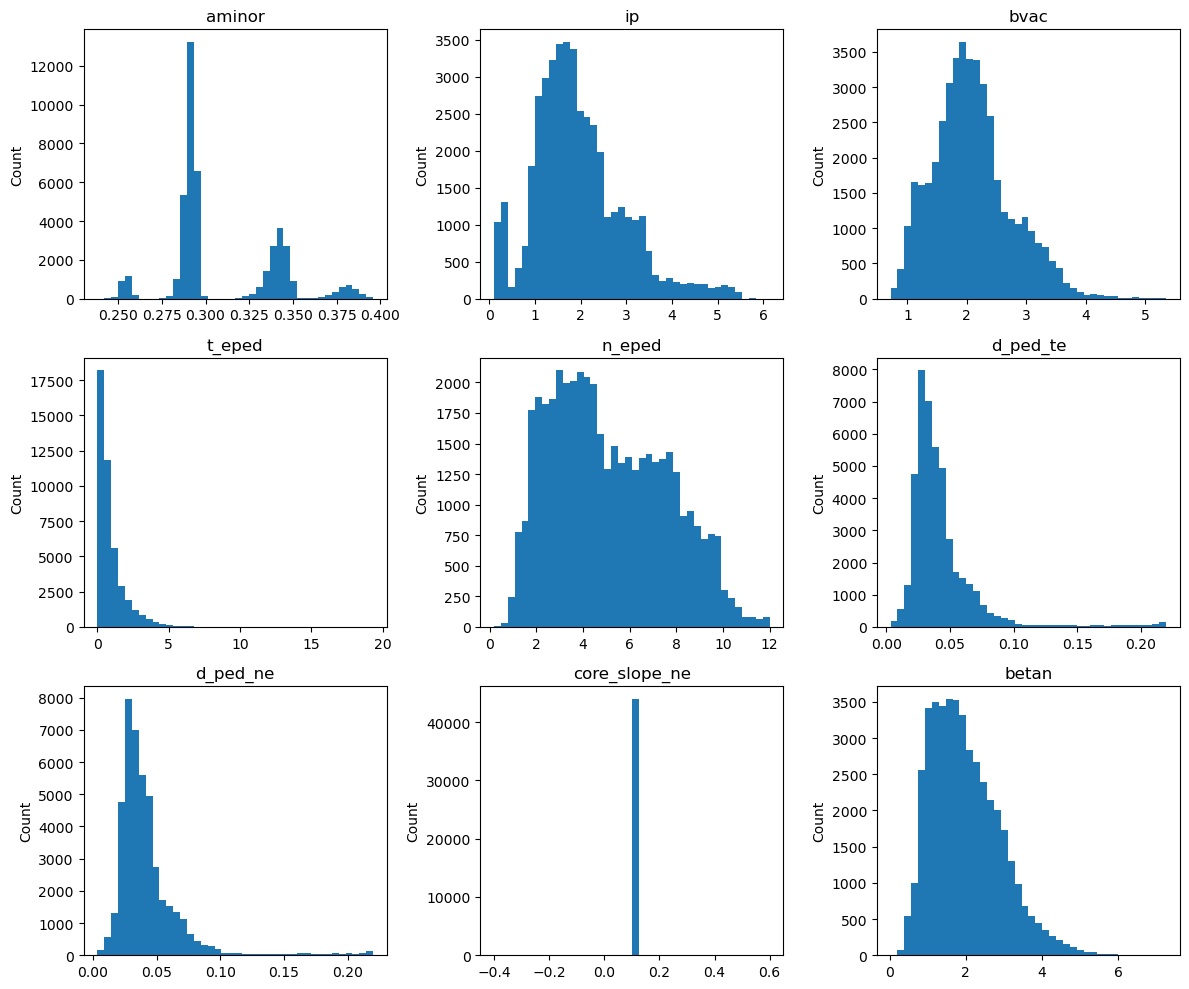

In [2]:
plot_feature_histograms(X)

In [3]:
X_train, X_test, y_train, y_test, scaler = preprocess_dataset(X, y)

In [4]:
model = train_model(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.9025421782939679
R2: 0.9825606878346046


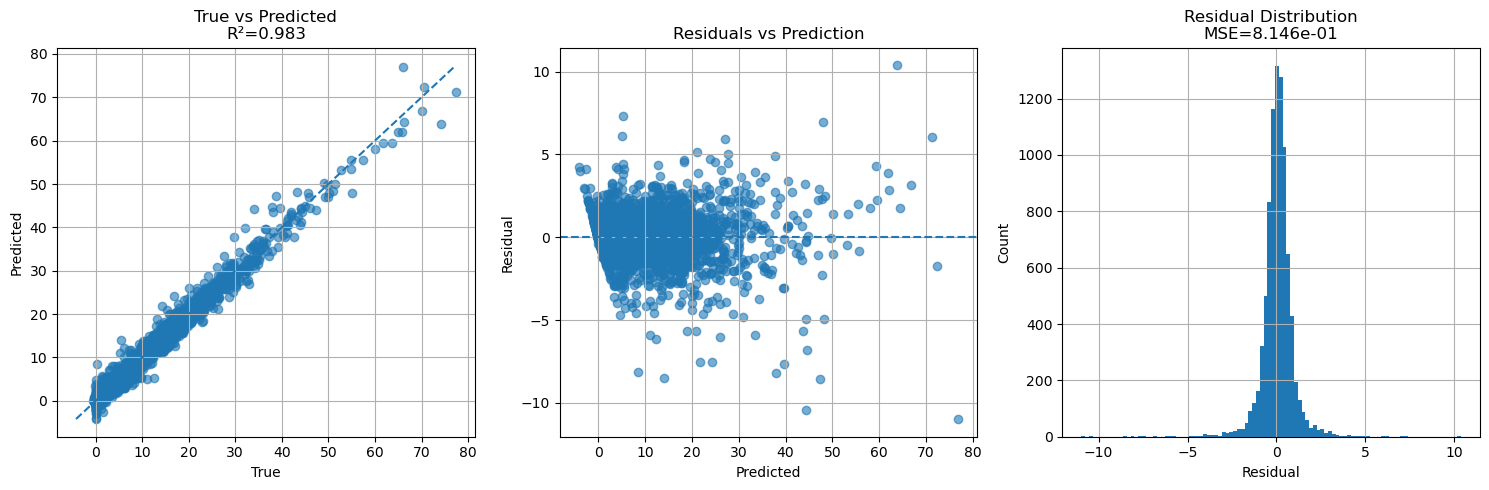

In [6]:
regression_diagnostics(y_test, y_pred)

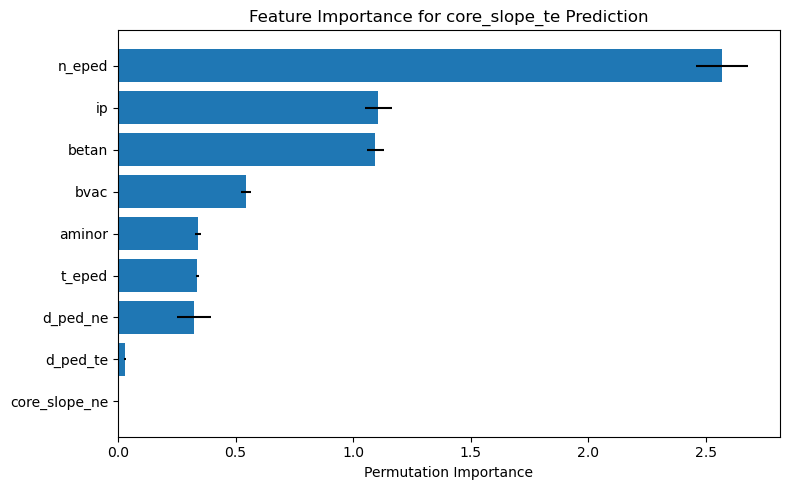

In [7]:
plot_feature_importance(model, X_test, y_test)

In [8]:
model_dir = "model"
save_model(model_dir, model, scaler)

## Load existing model


In [2]:
model_dir = "model"
model, scaler = load_model(model_dir)

In [5]:

aminor = 0.3
ip=1.0
bvac=1.0
t_eped=1.0
n_eped=1.0
d_ped_te=0.05
d_ped_ne=0.05
core_slope_ne=0.1
betan=1.0

x = np.array([[aminor, ip, bvac, t_eped, n_eped, d_ped_te, d_ped_ne, core_slope_ne, betan]])
x = np.array([[0.9253695/2.9, 1.3757, 1.684, 0.88691459, 2.60564576, 0.045, 0.045, 0.1, 1.5,]])
# x = np.array([[0.31927934, 1.3757,     1.684,      0.27373907, 2.60564576, 0.025,  0.025,      0.1,        1.5,       ]])

print(f"Unscaled x: {x}")
x = scaler.transform(x)
print(f"Scaled x: {x}")
y_pred = model.predict(x)

print(y_pred)

Unscaled x: [[0.31909293 1.3757     1.684      0.88691459 2.60564576 0.045
  0.045      0.1        1.5       ]]
Scaled x: [[ 3.24548419e-01 -5.88741313e-01 -6.18529474e-01 -5.41410530e-02
  -1.02542323e+00  7.46608719e-02  7.46608719e-02  5.98132655e-14
  -5.36952835e-01]]
[3.14380851]
